In [ ]:
import ROOT

File: /home/meenakshi/bragg-peak/build/B4_100000000.root
Bin size: 0.05 MeV
Minimum peak height: 100 counts
Total events in file: 14,282,849

Extracting energy data...
  Processed 1,000,000 events...
  Processed 2,000,000 events...
  Processed 3,000,000 events...
  Processed 4,000,000 events...
  Processed 5,000,000 events...
  Processed 6,000,000 events...
  Processed 7,000,000 events...
  Processed 8,000,000 events...
  Processed 9,000,000 events...
  Processed 10,000,000 events...
  Processed 11,000,000 events...
  Processed 12,000,000 events...
  Processed 13,000,000 events...
  Processed 14,000,000 events...
Events in 0-10 MeV range: 14,257,014

Finding peaks...
Found 7 significant peaks

PEAK ANALYSIS RESULTS:
Peak # Energy (MeV)    Counts       FWHM (MeV)   Area        
----------------------------------------------------------------------
1      0.125           456043       0.286        2612364     
2      2.825           68427        0.134        183550      
3      3.875     

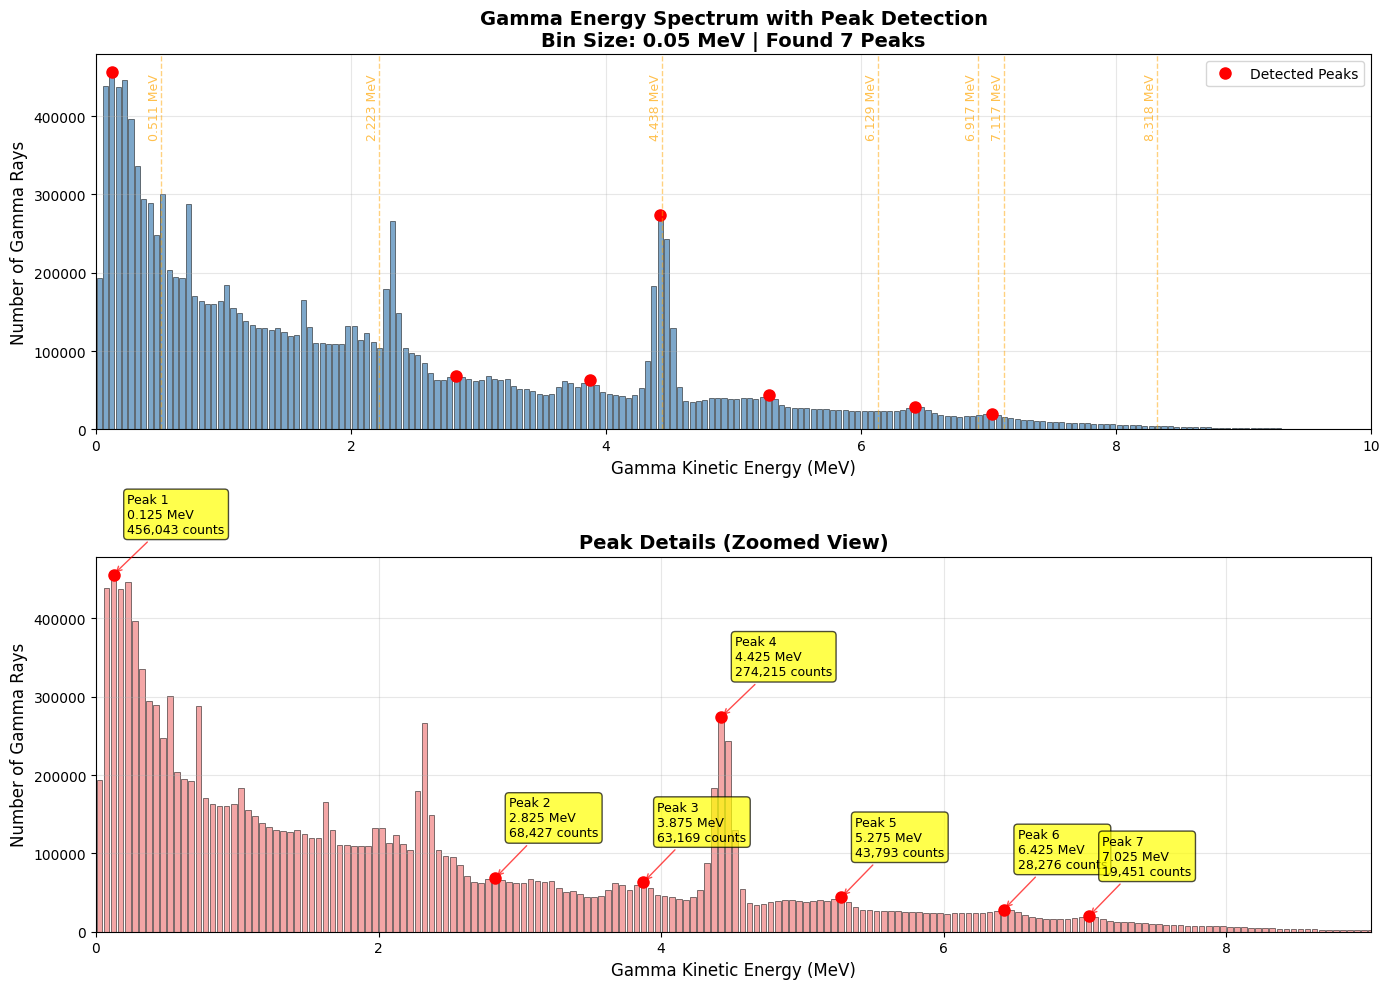


PEAK DETECTION SUMMARY:
File analyzed: /home/meenakshi/bragg-peak/build/B4_100000000.root
Total gamma events: 14,257,014
Bin size used: 0.05 MeV
Number of peaks found: 7
Peak with maximum counts: 0.125 MeV (456,043 counts)
Output files created:
  - gamma_peaks_detection_bin0.05MeV.png (plot with peaks marked)
  - gamma_peaks_data_bin0.05MeV.csv (peak data in CSV format)


In [3]:
import ROOT
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, peak_widths
import os

def find_gamma_peaks():
    """
    Find peaks in gamma energy spectrum and plot them
    """
    # ======= CONFIGURATION =======
    ROOT_FILE = "/home/meenakshi/bragg-peak/build/B4_100000000.root"
    BIN_SIZE = 0.05
    # MeV - Fine binning for better peak detection
    ENERGY_MAX = 10  # MeV - Maximum energy to analyze
    MIN_PEAK_HEIGHT = 100  # Minimum counts to consider as a peak
    MIN_PEAK_DISTANCE = 10  # Minimum distance between peaks (in bins)
    # =============================
    
    print(f"File: {ROOT_FILE}")
    print(f"Bin size: {BIN_SIZE} MeV")
    print(f"Minimum peak height: {MIN_PEAK_HEIGHT} counts")
    
    # 1. Check if file exists
    if not os.path.exists(ROOT_FILE):
        print(f"\n✗ ERROR: File not found!")
        return
    
    # 2. Open ROOT file
    file = ROOT.TFile(ROOT_FILE, "READ")
    if not file or file.IsZombie():
        print("ERROR: Cannot open ROOT file!")
        return
    
    # 3. Get the ntuple
    ntuple = file.Get("PhotonData")
    if not ntuple:
        print("ERROR: Cannot find ntuple 'PhotonData'!")
        file.Close()
        return
    
    total_entries = ntuple.GetEntries()
    print(f"Total events in file: {total_entries:,}")
    
    # 4. Extract energy data
    print("\nExtracting energy data...")
    
    energies = []
    energy_val = np.zeros(1, dtype=float)
    
    # Get energy branch
    ntuple.SetBranchStatus("*", 0)
    ntuple.SetBranchStatus("KineticEnergy", 1)
    branch_energy = ntuple.GetBranch("KineticEnergy")
    branch_energy.SetAddress(energy_val)
    
    # Read all entries
    for i in range(total_entries):
        ntuple.GetEntry(i)
        if energy_val[0] <= ENERGY_MAX:
            energies.append(energy_val[0])
        
        if (i+1) % 1000000 == 0:
            print(f"  Processed {i+1:,} events...")
    
    energies = np.array(energies)
    print(f"Events in 0-{ENERGY_MAX} MeV range: {len(energies):,}")
    
    # 5. Create histogram for peak finding
    num_bins = int(ENERGY_MAX / BIN_SIZE)
    bins = np.arange(0, ENERGY_MAX + BIN_SIZE, BIN_SIZE)
    
    counts, bin_edges = np.histogram(energies, bins=bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # 6. Find peaks
    print("\nFinding peaks...")
    
    # Find peaks using scipy
    peaks, properties = find_peaks(
        counts, 
        height=MIN_PEAK_HEIGHT,
        distance=MIN_PEAK_DISTANCE,
        prominence=50,  # Minimum prominence of peaks
        width=2  # Minimum width of peaks
    )
    
    print(f"Found {len(peaks)} significant peaks")
    
    if len(peaks) == 0:
        print("No peaks found. Try lowering MIN_PEAK_HEIGHT.")
        file.Close()
        return
    
    # 7. Calculate peak properties
    peak_energies = bin_centers[peaks]
    peak_counts = counts[peaks]
    
    # Calculate peak widths
    widths, width_heights, left_ips, right_ips = peak_widths(
        counts, peaks, rel_height=0.5
    )
    
    # Convert width indices to energy
    width_energies = widths * BIN_SIZE
    
    # 8. Print peak information
    print("\n" + "="*70)
    print("PEAK ANALYSIS RESULTS:")
    print("="*70)
    print(f"{'Peak #':<6} {'Energy (MeV)':<15} {'Counts':<12} {'FWHM (MeV)':<12} {'Area':<12}")
    print("-"*70)
    
    peak_areas = []
    for i, (energy, count, width) in enumerate(zip(peak_energies, peak_counts, width_energies), 1):
        # Estimate area under peak (simplified)
        area = count * width / BIN_SIZE
        peak_areas.append(area)
        
        print(f"{i:<6} {energy:<15.3f} {int(count):<12} {width:<12.3f} {area:<12.0f}")
    
    print("="*70)
    
    # 9. Known nuclear gamma lines for comparison
    known_lines = {
        0.511: "e⁺e⁻ annihilation",
        2.223: "n + p → d + γ (n capture)",
        4.438: "¹²C* de-excitation",
        6.129: "¹⁶O* de-excitation",
        6.917: "¹⁶O* de-excitation",
        7.117: "¹⁶O* de-excitation",
        8.318: "¹⁶O* de-excitation",
    }
    
    # 10. Match peaks with known lines
    print("\n" + "="*70)
    print("MATCHING WITH KNOWN NUCLEAR GAMMA LINES:")
    print("="*70)
    print(f"{'Measured':<12} {'Known':<12} {'Difference':<15} {'Identification':<20}")
    print("-"*70)
    
    for peak_energy in peak_energies:
        # Find closest known line
        closest_energy = min(known_lines.keys(), key=lambda x: abs(x - peak_energy))
        difference = abs(peak_energy - closest_energy)
        
        if difference < 0.05:  # Match within 50 keV
            print(f"{peak_energy:<12.3f} {closest_energy:<12.3f} {difference:<15.3f} {known_lines[closest_energy]:<20}")
        else:
            print(f"{peak_energy:<12.3f} {'?':<12} {difference:<15.3f} {'Unknown/background':<20}")
    
    print("="*70)
    
    # 11. Create detailed plot with peaks marked
    print("\nCreating plot with peaks marked...")
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
    
    # Top plot: Full spectrum with peaks
    ax1.bar(bin_centers, counts, width=BIN_SIZE*0.8, 
            alpha=0.7, color='steelblue', edgecolor='black', linewidth=0.5)
    
    # Mark peaks with red dots
    ax1.plot(peak_energies, peak_counts, 'ro', markersize=8, label='Detected Peaks')
    
    # Draw lines for known nuclear transitions
    for energy, label in known_lines.items():
        ax1.axvline(energy, color='orange', linestyle='--', alpha=0.5, linewidth=1)
        ax1.text(energy, ax1.get_ylim()[1]*0.95, f'{energy} MeV', 
                rotation=90, fontsize=9, color='orange', alpha=0.7,
                verticalalignment='top', horizontalalignment='right')
    
    ax1.set_xlabel('Gamma Kinetic Energy (MeV)', fontsize=12)
    ax1.set_ylabel('Number of Gamma Rays', fontsize=12)
    ax1.set_title(f'Gamma Energy Spectrum with Peak Detection\n'
                  f'Bin Size: {BIN_SIZE} MeV | Found {len(peaks)} Peaks',
                  fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, ENERGY_MAX)
    ax1.legend()
    
    # Bottom plot: Peak details (zoomed)
    ax2.bar(bin_centers, counts, width=BIN_SIZE*0.8, 
            alpha=0.7, color='lightcoral', edgecolor='black', linewidth=0.5)
    
    # Mark peaks
    ax2.plot(peak_energies, peak_counts, 'ro', markersize=8)
    
    # Annotate each peak
    for i, (energy, count) in enumerate(zip(peak_energies, peak_counts), 1):
        ax2.annotate(f'Peak {i}\n{energy:.3f} MeV\n{int(count):,} counts',
                    xy=(energy, count),
                    xytext=(10, 30),
                    textcoords='offset points',
                    arrowprops=dict(arrowstyle='->', color='red', alpha=0.7),
                    fontsize=9,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))
    
    # Set zoomed x-range around peaks
    if len(peak_energies) > 0:
        min_energy = max(0, peak_energies.min() - 2)
        max_energy = min(ENERGY_MAX, peak_energies.max() + 2)
        ax2.set_xlim(min_energy, max_energy)
    
    ax2.set_xlabel('Gamma Kinetic Energy (MeV)', fontsize=12)
    ax2.set_ylabel('Number of Gamma Rays', fontsize=12)
    ax2.set_title('Peak Details (Zoomed View)', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # 12. Save plot and data
    output_plot = f'gamma_peaks_detection_bin{BIN_SIZE}MeV.png'
    plt.savefig(output_plot, dpi=300, bbox_inches='tight')
    print(f"✓ Plot saved: {output_plot}")
    
    # Save peak data to CSV
    import pandas as pd
    peak_data = pd.DataFrame({
        'Peak_Number': range(1, len(peaks)+1),
        'Energy_MeV': peak_energies,
        'Counts': peak_counts,
        'FWHM_MeV': width_energies,
        'Area': peak_areas,
        'Left_Edge_MeV': bin_edges[peaks],
        'Right_Edge_MeV': bin_edges[peaks+1]
    })
    
    csv_file = f'gamma_peaks_data_bin{BIN_SIZE}MeV.csv'
    peak_data.to_csv(csv_file, index=False)
    print(f"✓ Peak data saved: {csv_file}")
    
    # 13. Close ROOT file and show plot
    file.Close()
    plt.show()
    
    # 14. Print summary
    print("\n" + "="*70)
    print("PEAK DETECTION SUMMARY:")
    print("="*70)
    print(f"File analyzed: {ROOT_FILE}")
    print(f"Total gamma events: {len(energies):,}")
    print(f"Bin size used: {BIN_SIZE} MeV")
    print(f"Number of peaks found: {len(peaks)}")
    print(f"Peak with maximum counts: {peak_energies[peak_counts.argmax()]:.3f} MeV ({peak_counts.max():,} counts)")
    print(f"Output files created:")
    print(f"  - {output_plot} (plot with peaks marked)")
    print(f"  - {csv_file} (peak data in CSV format)")
    print("="*70)

# Run the analysis
if __name__ == "__main__":
    find_gamma_peaks()

File: /home/meenakshi/bragg-peak/build/B4_100000000.root
Bin size: 0.05 MeV
Energy range: 0-10 MeV
Total events in file: 14,282,849

Extracting energy data...
  Processed 1,000,000 events...
  Processed 2,000,000 events...
  Processed 3,000,000 events...
  Processed 4,000,000 events...
  Processed 5,000,000 events...
  Processed 6,000,000 events...
  Processed 7,000,000 events...
  Processed 8,000,000 events...
  Processed 9,000,000 events...
  Processed 10,000,000 events...
  Processed 11,000,000 events...
  Processed 12,000,000 events...
  Processed 13,000,000 events...
  Processed 14,000,000 events...
Events in 0-10 MeV range: 14,257,014

Creating plot...
✓ Plot saved: gamma_energy_spectrum_bin0.05MeV.png
✓ Data saved: gamma_energy_data_bin0.05MeV.txt


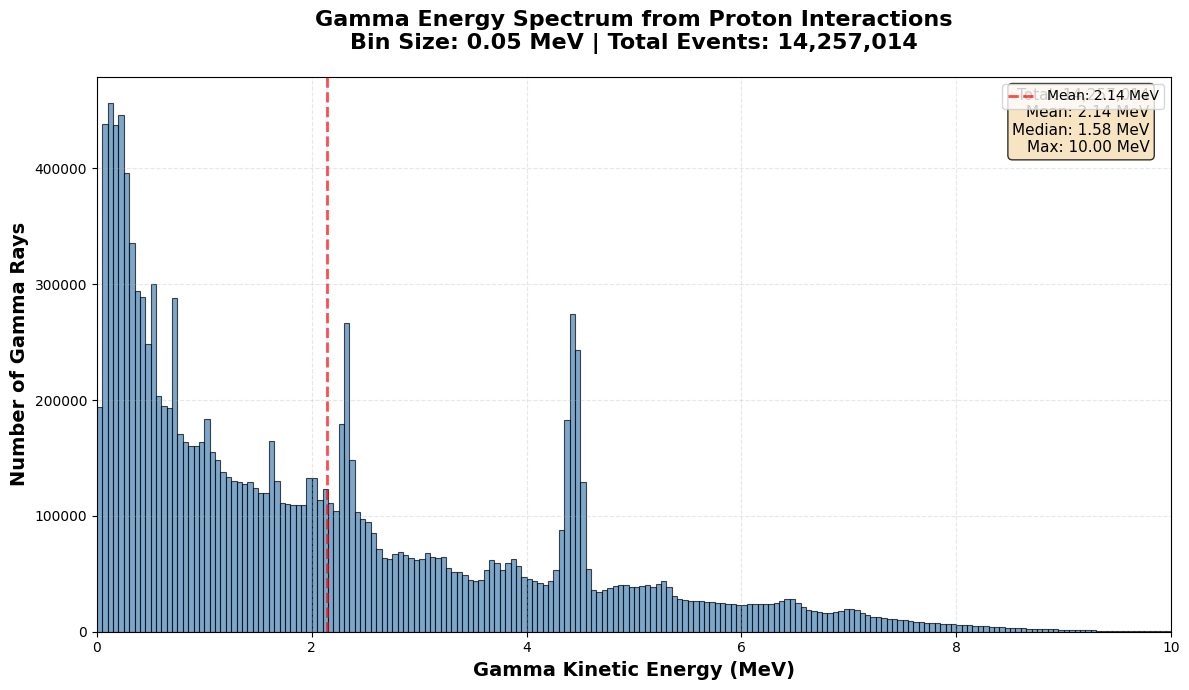


ANALYSIS SUMMARY:
File analyzed: /home/meenakshi/bragg-peak/build/B4_100000000.root
Total gamma events: 14,257,014
Bin size used: 0.05 MeV
Energy range: 0-10 MeV
Mean energy: 2.143 MeV
Median energy: 1.583 MeV
Maximum energy: 10.000 MeV
Output files created:
  - gamma_energy_spectrum_bin0.05MeV.png (plot)
  - gamma_energy_data_bin0.05MeV.txt (data)


In [5]:
import ROOT
import numpy as np
import matplotlib.pyplot as plt
import os

def plot_gamma_energy_spectrum():
    """
    Simple plot: Gamma energy vs Number of particles
    """
    # ======= CONFIGURATION =======
    ROOT_FILE = "/home/meenakshi/bragg-peak/build/B4_100000000.root"
    BIN_SIZE = 0.05  # MeV - CHANGE THIS TO ADJUST BIN SIZE
    ENERGY_MAX = 10  # MeV - Maximum energy to plot
    # =============================
    
    print(f"File: {ROOT_FILE}")
    print(f"Bin size: {BIN_SIZE} MeV")
    print(f"Energy range: 0-{ENERGY_MAX} MeV")
    
    # 1. Check if file exists
    if not os.path.exists(ROOT_FILE):
        print(f"\n✗ ERROR: File not found!")
        return
    
    # 2. Open ROOT file
    file = ROOT.TFile(ROOT_FILE, "READ")
    if not file or file.IsZombie():
        print("ERROR: Cannot open ROOT file!")
        return
    
    # 3. Get the ntuple
    ntuple = file.Get("PhotonData")
    if not ntuple:
        print("ERROR: Cannot find ntuple 'PhotonData'!")
        file.Close()
        return
    
    total_entries = ntuple.GetEntries()
    print(f"Total events in file: {total_entries:,}")
    
    # 4. Extract energy data
    print("\nExtracting energy data...")
    
    energies = []
    energy_val = np.zeros(1, dtype=float)
    
    # Get energy branch
    ntuple.SetBranchStatus("*", 0)
    ntuple.SetBranchStatus("KineticEnergy", 1)
    branch_energy = ntuple.GetBranch("KineticEnergy")
    branch_energy.SetAddress(energy_val)
    
    # Read all entries
    for i in range(total_entries):
        ntuple.GetEntry(i)
        if energy_val[0] <= ENERGY_MAX:  # Only keep up to ENERGY_MAX
            energies.append(energy_val[0])
        
        # Progress
        if (i+1) % 1000000 == 0:
            print(f"  Processed {i+1:,} events...")
    
    energies = np.array(energies)
    print(f"Events in 0-{ENERGY_MAX} MeV range: {len(energies):,}")
    
    # 5. Create histogram
    print("\nCreating plot...")
    
    # Calculate bins based on bin size
    num_bins = int(ENERGY_MAX / BIN_SIZE)
    bins = np.arange(0, ENERGY_MAX + BIN_SIZE, BIN_SIZE)
    
    # Create figure
    plt.figure(figsize=(12, 7))
    
    # Plot histogram
    counts, bin_edges, patches = plt.hist(energies, bins=bins,
                                          alpha=0.7, color='steelblue',
                                          edgecolor='black', linewidth=0.8)
    
    # Customize plot
    plt.xlabel('Gamma Kinetic Energy (MeV)', fontsize=14, fontweight='bold')
    plt.ylabel('Number of Gamma Rays', fontsize=14, fontweight='bold')
    plt.title(f'Gamma Energy Spectrum from Proton Interactions\n'
              f'Bin Size: {BIN_SIZE} MeV | Total Events: {len(energies):,}',
              fontsize=16, fontweight='bold', pad=20)
    
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.xlim(0, ENERGY_MAX)
    
    # Add statistics box
    stats_text = (f'Total: {len(energies):,}\n'
                  f'Mean: {np.mean(energies):.2f} MeV\n'
                  f'Median: {np.median(energies):.2f} MeV\n'
                  f'Max: {np.max(energies):.2f} MeV')
    
    plt.text(0.98, 0.98, stats_text,
             transform=plt.gca().transAxes,
             verticalalignment='top',
             horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
             fontsize=11)
    
    # Add mean line
    plt.axvline(np.mean(energies), color='red', linestyle='--', 
                linewidth=2, alpha=0.7, label=f'Mean: {np.mean(energies):.2f} MeV')
    
    plt.legend(loc='upper right')
    plt.tight_layout()
    
    # 6. Save plot
    output_file = f'gamma_energy_spectrum_bin{BIN_SIZE}MeV.png'
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"✓ Plot saved: {output_file}")
    
    # 7. Save data to text file
    data_file = f'gamma_energy_data_bin{BIN_SIZE}MeV.txt'
    with open(data_file, 'w') as f:
        f.write(f"# Gamma Energy Spectrum Data\n")
        f.write(f"# Bin Size: {BIN_SIZE} MeV\n")
        f.write(f"# Total Events: {len(energies)}\n")
        f.write("# Bin_Center(MeV) Count Count_Per_MeV\n")
        
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        for center, count in zip(bin_centers, counts):
            count_per_mev = count / BIN_SIZE
            f.write(f"{center:.3f} {int(count)} {count_per_mev:.2f}\n")
    
    print(f"✓ Data saved: {data_file}")
    
    # 8. Close ROOT file and show plot
    file.Close()
    plt.show()
    
    # Print summary
    print("\n" + "="*50)
    print("ANALYSIS SUMMARY:")
    print("="*50)
    print(f"File analyzed: {ROOT_FILE}")
    print(f"Total gamma events: {len(energies):,}")
    print(f"Bin size used: {BIN_SIZE} MeV")
    print(f"Energy range: 0-{ENERGY_MAX} MeV")
    print(f"Mean energy: {np.mean(energies):.3f} MeV")
    print(f"Median energy: {np.median(energies):.3f} MeV")
    print(f"Maximum energy: {np.max(energies):.3f} MeV")
    print(f"Output files created:")
    print(f"  - {output_file} (plot)")
    print(f"  - {data_file} (data)")
    print("="*50)

# Run the analysis
if __name__ == "__main__":
    plot_gamma_energy_spectrum()

File: /home/meenakshi/bragg-peak/build/B4_100000000.root
Bin size: 0.01 MeV
Energy range: 0-10 MeV
Total events in file: 14,282,849

Extracting energy data...
  Processed 1,000,000 events...
  Processed 2,000,000 events...
  Processed 3,000,000 events...
  Processed 4,000,000 events...
  Processed 5,000,000 events...
  Processed 6,000,000 events...
  Processed 7,000,000 events...
  Processed 8,000,000 events...
  Processed 9,000,000 events...
  Processed 10,000,000 events...
  Processed 11,000,000 events...
  Processed 12,000,000 events...
  Processed 13,000,000 events...
  Processed 14,000,000 events...
Events in 0-10 MeV range: 14,257,014

Creating plot...
✓ Plot saved: gamma_energy_spectrum_bin0.01MeV.png
✓ Data saved: gamma_energy_data_bin0.01MeV.txt


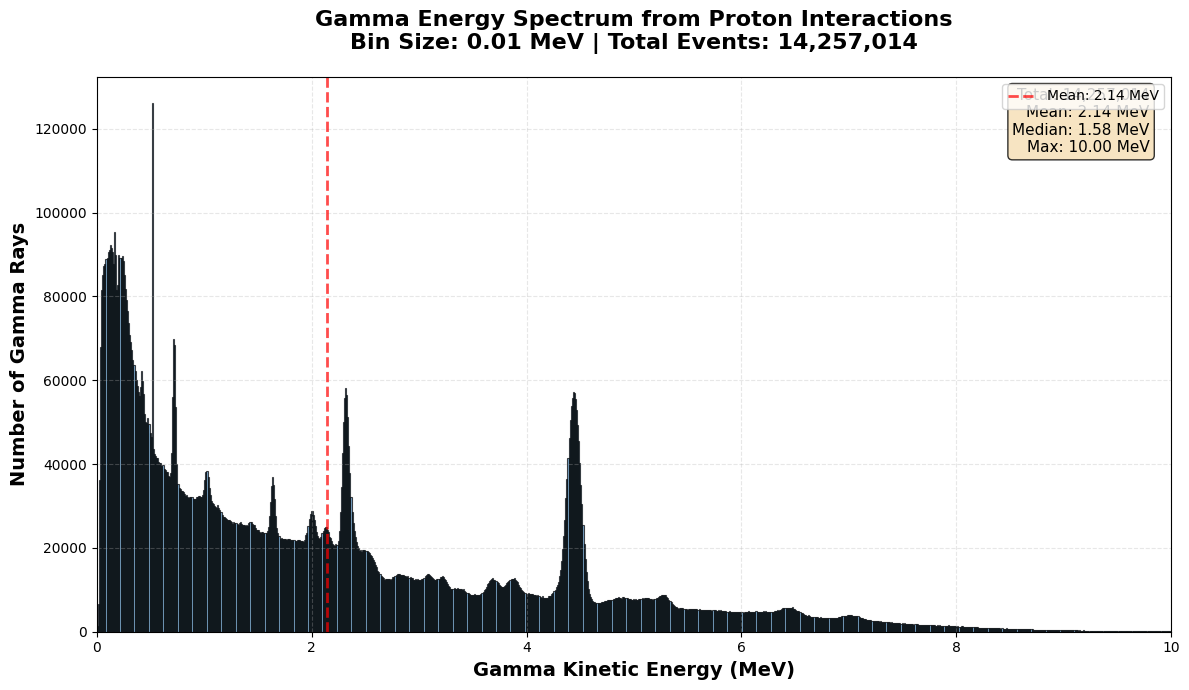


ANALYSIS SUMMARY:
File analyzed: /home/meenakshi/bragg-peak/build/B4_100000000.root
Total gamma events: 14,257,014
Bin size used: 0.01 MeV
Energy range: 0-10 MeV
Mean energy: 2.143 MeV
Median energy: 1.583 MeV
Maximum energy: 10.000 MeV
Output files created:
  - gamma_energy_spectrum_bin0.01MeV.png (plot)
  - gamma_energy_data_bin0.01MeV.txt (data)


In [6]:
import ROOT
import numpy as np
import matplotlib.pyplot as plt
import os

def plot_gamma_energy_spectrum():
    """
    Simple plot: Gamma energy vs Number of particles
    """
    # ======= CONFIGURATION =======
    ROOT_FILE = "/home/meenakshi/bragg-peak/build/B4_100000000.root"
    BIN_SIZE = 0.01  # MeV - CHANGE THIS TO ADJUST BIN SIZE
    ENERGY_MAX = 10  # MeV - Maximum energy to plot
    # =============================
    
    print(f"File: {ROOT_FILE}")
    print(f"Bin size: {BIN_SIZE} MeV")
    print(f"Energy range: 0-{ENERGY_MAX} MeV")
    
    # 1. Check if file exists
    if not os.path.exists(ROOT_FILE):
        print(f"\n✗ ERROR: File not found!")
        return
    
    # 2. Open ROOT file
    file = ROOT.TFile(ROOT_FILE, "READ")
    if not file or file.IsZombie():
        print("ERROR: Cannot open ROOT file!")
        return
    
    # 3. Get the ntuple
    ntuple = file.Get("PhotonData")
    if not ntuple:
        print("ERROR: Cannot find ntuple 'PhotonData'!")
        file.Close()
        return
    
    total_entries = ntuple.GetEntries()
    print(f"Total events in file: {total_entries:,}")
    
    # 4. Extract energy data
    print("\nExtracting energy data...")
    
    energies = []
    energy_val = np.zeros(1, dtype=float)
    
    # Get energy branch
    ntuple.SetBranchStatus("*", 0)
    ntuple.SetBranchStatus("KineticEnergy", 1)
    branch_energy = ntuple.GetBranch("KineticEnergy")
    branch_energy.SetAddress(energy_val)
    
    # Read all entries
    for i in range(total_entries):
        ntuple.GetEntry(i)
        if energy_val[0] <= ENERGY_MAX:  # Only keep up to ENERGY_MAX
            energies.append(energy_val[0])
        
        # Progress
        if (i+1) % 1000000 == 0:
            print(f"  Processed {i+1:,} events...")
    
    energies = np.array(energies)
    print(f"Events in 0-{ENERGY_MAX} MeV range: {len(energies):,}")
    
    # 5. Create histogram
    print("\nCreating plot...")
    
    # Calculate bins based on bin size
    num_bins = int(ENERGY_MAX / BIN_SIZE)
    bins = np.arange(0, ENERGY_MAX + BIN_SIZE, BIN_SIZE)
    
    # Create figure
    plt.figure(figsize=(12, 7))
    
    # Plot histogram
    counts, bin_edges, patches = plt.hist(energies, bins=bins,
                                          alpha=0.7, color='steelblue',
                                          edgecolor='black', linewidth=0.8)
    
    # Customize plot
    plt.xlabel('Gamma Kinetic Energy (MeV)', fontsize=14, fontweight='bold')
    plt.ylabel('Number of Gamma Rays', fontsize=14, fontweight='bold')
    plt.title(f'Gamma Energy Spectrum from Proton Interactions\n'
              f'Bin Size: {BIN_SIZE} MeV | Total Events: {len(energies):,}',
              fontsize=16, fontweight='bold', pad=20)
    
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.xlim(0, ENERGY_MAX)
    
    # Add statistics box
    stats_text = (f'Total: {len(energies):,}\n'
                  f'Mean: {np.mean(energies):.2f} MeV\n'
                  f'Median: {np.median(energies):.2f} MeV\n'
                  f'Max: {np.max(energies):.2f} MeV')
    
    plt.text(0.98, 0.98, stats_text,
             transform=plt.gca().transAxes,
             verticalalignment='top',
             horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
             fontsize=11)
    
    # Add mean line
    plt.axvline(np.mean(energies), color='red', linestyle='--', 
                linewidth=2, alpha=0.7, label=f'Mean: {np.mean(energies):.2f} MeV')
    
    plt.legend(loc='upper right')
    plt.tight_layout()
    
    # 6. Save plot
    output_file = f'gamma_energy_spectrum_bin{BIN_SIZE}MeV.png'
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"✓ Plot saved: {output_file}")
    
    # 7. Save data to text file
    data_file = f'gamma_energy_data_bin{BIN_SIZE}MeV.txt'
    with open(data_file, 'w') as f:
        f.write(f"# Gamma Energy Spectrum Data\n")
        f.write(f"# Bin Size: {BIN_SIZE} MeV\n")
        f.write(f"# Total Events: {len(energies)}\n")
        f.write("# Bin_Center(MeV) Count Count_Per_MeV\n")
        
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        for center, count in zip(bin_centers, counts):
            count_per_mev = count / BIN_SIZE
            f.write(f"{center:.3f} {int(count)} {count_per_mev:.2f}\n")
    
    print(f"✓ Data saved: {data_file}")
    
    # 8. Close ROOT file and show plot
    file.Close()
    plt.show()
    
    # Print summary
    print("\n" + "="*50)
    print("ANALYSIS SUMMARY:")
    print("="*50)
    print(f"File analyzed: {ROOT_FILE}")
    print(f"Total gamma events: {len(energies):,}")
    print(f"Bin size used: {BIN_SIZE} MeV")
    print(f"Energy range: 0-{ENERGY_MAX} MeV")
    print(f"Mean energy: {np.mean(energies):.3f} MeV")
    print(f"Median energy: {np.median(energies):.3f} MeV")
    print(f"Maximum energy: {np.max(energies):.3f} MeV")
    print(f"Output files created:")
    print(f"  - {output_file} (plot)")
    print(f"  - {data_file} (data)")
    print("="*50)

# Run the analysis
if __name__ == "__main__":
    plot_gamma_energy_spectrum()

File: /home/meenakshi/bragg-peak/build/B4_100000000.root
Bin size: 0.01 MeV
Minimum peak height: 100 counts
Total events in file: 14,282,849

Extracting energy data...
  Processed 1,000,000 events...
  Processed 2,000,000 events...
  Processed 3,000,000 events...
  Processed 4,000,000 events...
  Processed 5,000,000 events...
  Processed 6,000,000 events...
  Processed 7,000,000 events...
  Processed 8,000,000 events...
  Processed 9,000,000 events...
  Processed 10,000,000 events...
  Processed 11,000,000 events...
  Processed 12,000,000 events...
  Processed 13,000,000 events...
  Processed 14,000,000 events...
Events in 0-10 MeV range: 14,257,014

Finding peaks...
Found 30 significant peaks

PEAK ANALYSIS RESULTS:
Peak # Energy (MeV)    Counts       FWHM (MeV)   Area        
----------------------------------------------------------------------
1      0.165           95370        0.268        2555889     
2      0.715           69805        0.032        224679      
3      1.025    

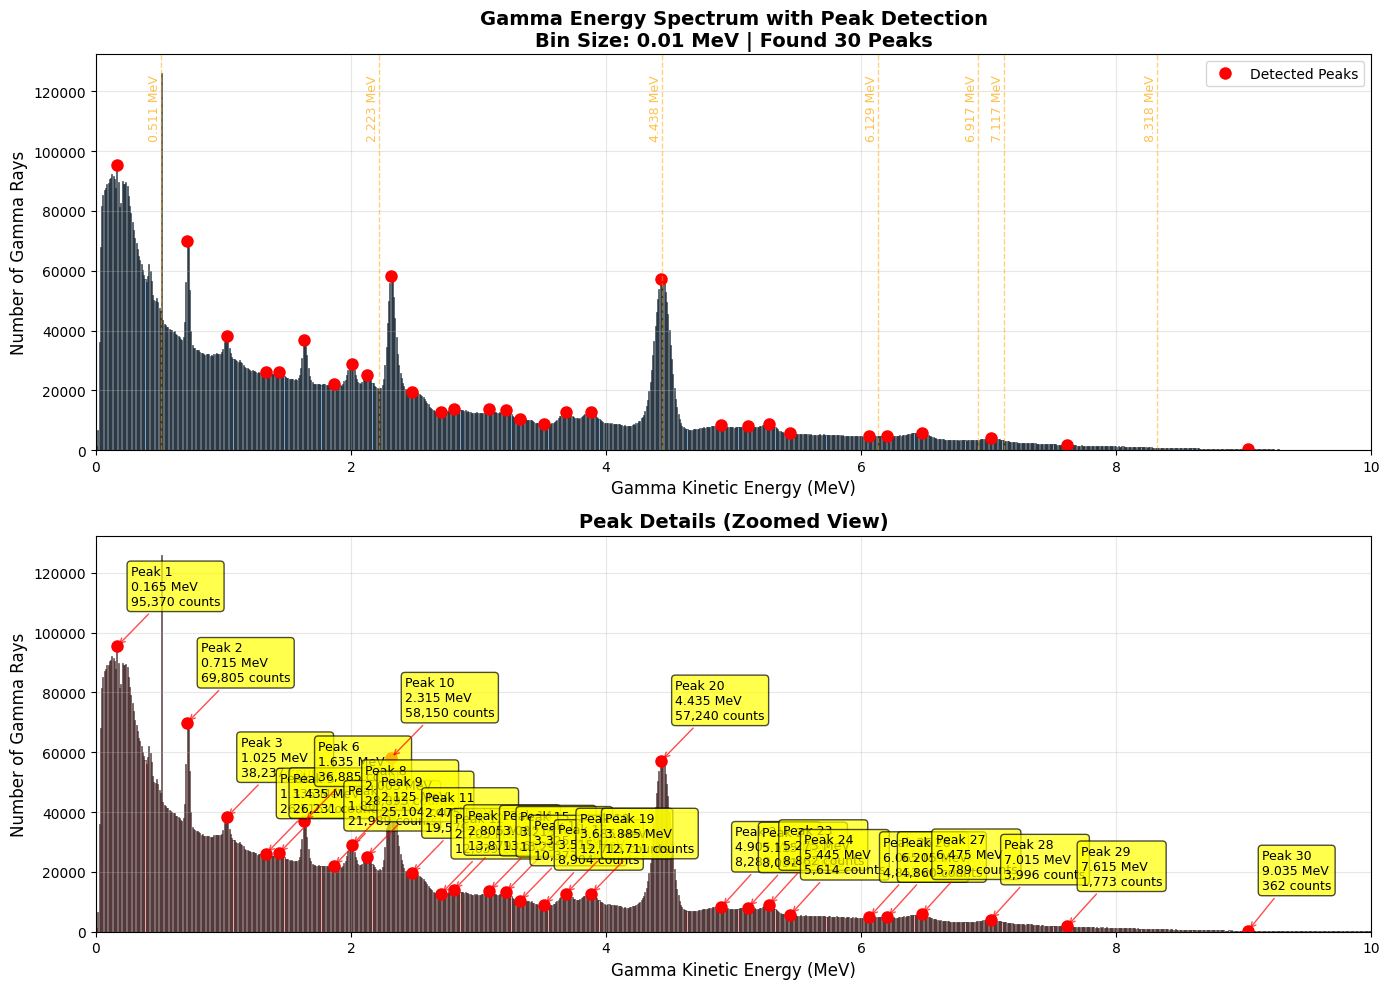


PEAK DETECTION SUMMARY:
File analyzed: /home/meenakshi/bragg-peak/build/B4_100000000.root
Total gamma events: 14,257,014
Bin size used: 0.01 MeV
Number of peaks found: 30
Peak with maximum counts: 0.165 MeV (95,370 counts)
Output files created:
  - gamma_peaks_detection_bin0.01MeV.png (plot with peaks marked)
  - gamma_peaks_data_bin0.01MeV.csv (peak data in CSV format)


In [7]:
import ROOT
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, peak_widths
import os

def find_gamma_peaks():
    """
    Find peaks in gamma energy spectrum and plot them
    """
    # ======= CONFIGURATION =======
    ROOT_FILE = "/home/meenakshi/bragg-peak/build/B4_100000000.root"
    BIN_SIZE = 0.01
    # MeV - Fine binning for better peak detection
    ENERGY_MAX = 10  # MeV - Maximum energy to analyze
    MIN_PEAK_HEIGHT = 100  # Minimum counts to consider as a peak
    MIN_PEAK_DISTANCE = 10  # Minimum distance between peaks (in bins)
    # =============================
    
    print(f"File: {ROOT_FILE}")
    print(f"Bin size: {BIN_SIZE} MeV")
    print(f"Minimum peak height: {MIN_PEAK_HEIGHT} counts")
    
    # 1. Check if file exists
    if not os.path.exists(ROOT_FILE):
        print(f"\n✗ ERROR: File not found!")
        return
    
    # 2. Open ROOT file
    file = ROOT.TFile(ROOT_FILE, "READ")
    if not file or file.IsZombie():
        print("ERROR: Cannot open ROOT file!")
        return
    
    # 3. Get the ntuple
    ntuple = file.Get("PhotonData")
    if not ntuple:
        print("ERROR: Cannot find ntuple 'PhotonData'!")
        file.Close()
        return
    
    total_entries = ntuple.GetEntries()
    print(f"Total events in file: {total_entries:,}")
    
    # 4. Extract energy data
    print("\nExtracting energy data...")
    
    energies = []
    energy_val = np.zeros(1, dtype=float)
    
    # Get energy branch
    ntuple.SetBranchStatus("*", 0)
    ntuple.SetBranchStatus("KineticEnergy", 1)
    branch_energy = ntuple.GetBranch("KineticEnergy")
    branch_energy.SetAddress(energy_val)
    
    # Read all entries
    for i in range(total_entries):
        ntuple.GetEntry(i)
        if energy_val[0] <= ENERGY_MAX:
            energies.append(energy_val[0])
        
        if (i+1) % 1000000 == 0:
            print(f"  Processed {i+1:,} events...")
    
    energies = np.array(energies)
    print(f"Events in 0-{ENERGY_MAX} MeV range: {len(energies):,}")
    
    # 5. Create histogram for peak finding
    num_bins = int(ENERGY_MAX / BIN_SIZE)
    bins = np.arange(0, ENERGY_MAX + BIN_SIZE, BIN_SIZE)
    
    counts, bin_edges = np.histogram(energies, bins=bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # 6. Find peaks
    print("\nFinding peaks...")
    
    # Find peaks using scipy
    peaks, properties = find_peaks(
        counts, 
        height=MIN_PEAK_HEIGHT,
        distance=MIN_PEAK_DISTANCE,
        prominence=50,  # Minimum prominence of peaks
        width=2  # Minimum width of peaks
    )
    
    print(f"Found {len(peaks)} significant peaks")
    
    if len(peaks) == 0:
        print("No peaks found. Try lowering MIN_PEAK_HEIGHT.")
        file.Close()
        return
    
    # 7. Calculate peak properties
    peak_energies = bin_centers[peaks]
    peak_counts = counts[peaks]
    
    # Calculate peak widths
    widths, width_heights, left_ips, right_ips = peak_widths(
        counts, peaks, rel_height=0.5
    )
    
    # Convert width indices to energy
    width_energies = widths * BIN_SIZE
    
    # 8. Print peak information
    print("\n" + "="*70)
    print("PEAK ANALYSIS RESULTS:")
    print("="*70)
    print(f"{'Peak #':<6} {'Energy (MeV)':<15} {'Counts':<12} {'FWHM (MeV)':<12} {'Area':<12}")
    print("-"*70)
    
    peak_areas = []
    for i, (energy, count, width) in enumerate(zip(peak_energies, peak_counts, width_energies), 1):
        # Estimate area under peak (simplified)
        area = count * width / BIN_SIZE
        peak_areas.append(area)
        
        print(f"{i:<6} {energy:<15.3f} {int(count):<12} {width:<12.3f} {area:<12.0f}")
    
    print("="*70)
    
    # 9. Known nuclear gamma lines for comparison
    known_lines = {
        0.511: "e⁺e⁻ annihilation",
        2.223: "n + p → d + γ (n capture)",
        4.438: "¹²C* de-excitation",
        6.129: "¹⁶O* de-excitation",
        6.917: "¹⁶O* de-excitation",
        7.117: "¹⁶O* de-excitation",
        8.318: "¹⁶O* de-excitation",
    }
    
    # 10. Match peaks with known lines
    print("\n" + "="*70)
    print("MATCHING WITH KNOWN NUCLEAR GAMMA LINES:")
    print("="*70)
    print(f"{'Measured':<12} {'Known':<12} {'Difference':<15} {'Identification':<20}")
    print("-"*70)
    
    for peak_energy in peak_energies:
        # Find closest known line
        closest_energy = min(known_lines.keys(), key=lambda x: abs(x - peak_energy))
        difference = abs(peak_energy - closest_energy)
        
        if difference < 0.05:  # Match within 50 keV
            print(f"{peak_energy:<12.3f} {closest_energy:<12.3f} {difference:<15.3f} {known_lines[closest_energy]:<20}")
        else:
            print(f"{peak_energy:<12.3f} {'?':<12} {difference:<15.3f} {'Unknown/background':<20}")
    
    print("="*70)
    
    # 11. Create detailed plot with peaks marked
    print("\nCreating plot with peaks marked...")
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
    
    # Top plot: Full spectrum with peaks
    ax1.bar(bin_centers, counts, width=BIN_SIZE*0.8, 
            alpha=0.7, color='steelblue', edgecolor='black', linewidth=0.5)
    
    # Mark peaks with red dots
    ax1.plot(peak_energies, peak_counts, 'ro', markersize=8, label='Detected Peaks')
    
    # Draw lines for known nuclear transitions
    for energy, label in known_lines.items():
        ax1.axvline(energy, color='orange', linestyle='--', alpha=0.5, linewidth=1)
        ax1.text(energy, ax1.get_ylim()[1]*0.95, f'{energy} MeV', 
                rotation=90, fontsize=9, color='orange', alpha=0.7,
                verticalalignment='top', horizontalalignment='right')
    
    ax1.set_xlabel('Gamma Kinetic Energy (MeV)', fontsize=12)
    ax1.set_ylabel('Number of Gamma Rays', fontsize=12)
    ax1.set_title(f'Gamma Energy Spectrum with Peak Detection\n'
                  f'Bin Size: {BIN_SIZE} MeV | Found {len(peaks)} Peaks',
                  fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, ENERGY_MAX)
    ax1.legend()
    
    # Bottom plot: Peak details (zoomed)
    ax2.bar(bin_centers, counts, width=BIN_SIZE*0.8, 
            alpha=0.7, color='lightcoral', edgecolor='black', linewidth=0.5)
    
    # Mark peaks
    ax2.plot(peak_energies, peak_counts, 'ro', markersize=8)
    
    # Annotate each peak
    for i, (energy, count) in enumerate(zip(peak_energies, peak_counts), 1):
        ax2.annotate(f'Peak {i}\n{energy:.3f} MeV\n{int(count):,} counts',
                    xy=(energy, count),
                    xytext=(10, 30),
                    textcoords='offset points',
                    arrowprops=dict(arrowstyle='->', color='red', alpha=0.7),
                    fontsize=9,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))
    
    # Set zoomed x-range around peaks
    if len(peak_energies) > 0:
        min_energy = max(0, peak_energies.min() - 2)
        max_energy = min(ENERGY_MAX, peak_energies.max() + 2)
        ax2.set_xlim(min_energy, max_energy)
    
    ax2.set_xlabel('Gamma Kinetic Energy (MeV)', fontsize=12)
    ax2.set_ylabel('Number of Gamma Rays', fontsize=12)
    ax2.set_title('Peak Details (Zoomed View)', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # 12. Save plot and data
    output_plot = f'gamma_peaks_detection_bin{BIN_SIZE}MeV.png'
    plt.savefig(output_plot, dpi=300, bbox_inches='tight')
    print(f"✓ Plot saved: {output_plot}")
    
    # Save peak data to CSV
    import pandas as pd
    peak_data = pd.DataFrame({
        'Peak_Number': range(1, len(peaks)+1),
        'Energy_MeV': peak_energies,
        'Counts': peak_counts,
        'FWHM_MeV': width_energies,
        'Area': peak_areas,
        'Left_Edge_MeV': bin_edges[peaks],
        'Right_Edge_MeV': bin_edges[peaks+1]
    })
    
    csv_file = f'gamma_peaks_data_bin{BIN_SIZE}MeV.csv'
    peak_data.to_csv(csv_file, index=False)
    print(f"✓ Peak data saved: {csv_file}")
    
    # 13. Close ROOT file and show plot
    file.Close()
    plt.show()
    
    # 14. Print summary
    print("\n" + "="*70)
    print("PEAK DETECTION SUMMARY:")
    print("="*70)
    print(f"File analyzed: {ROOT_FILE}")
    print(f"Total gamma events: {len(energies):,}")
    print(f"Bin size used: {BIN_SIZE} MeV")
    print(f"Number of peaks found: {len(peaks)}")
    print(f"Peak with maximum counts: {peak_energies[peak_counts.argmax()]:.3f} MeV ({peak_counts.max():,} counts)")
    print(f"Output files created:")
    print(f"  - {output_plot} (plot with peaks marked)")
    print(f"  - {csv_file} (peak data in CSV format)")
    print("="*70)

# Run the analysis
if __name__ == "__main__":
    find_gamma_peaks()

Analyzing: /home/meenakshi/bragg-peak/build/B4_100000000.root
Events analyzed: 100,416

✓ Plot saved: gamma_depth_plot.png


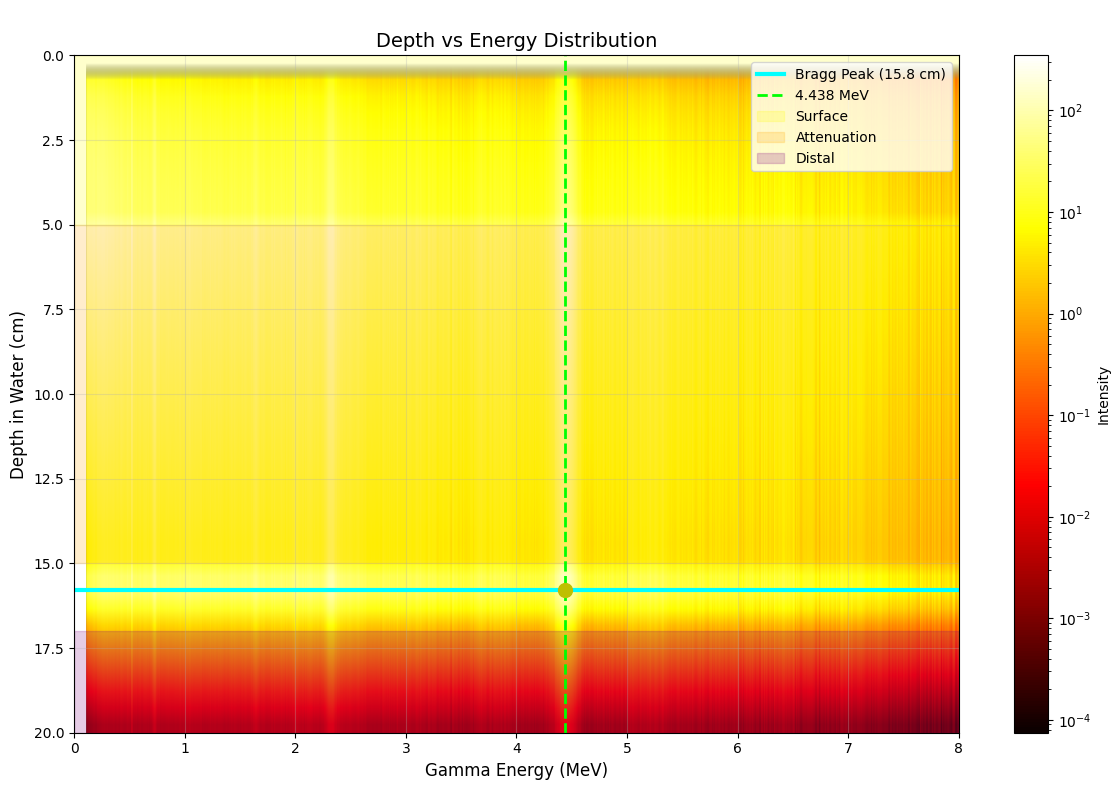

In [11]:
import ROOT
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import os

def find_gamma_peaks_with_bragg_mark():
    # CONFIG
    ROOT_FILE = "/home/meenakshi/bragg-peak/build/B4_100000000.root"
    BRAGG_DEPTH = 15.8
    BRAGG_GAMMA_ENERGY = 4.438
    
    print(f"Analyzing: {ROOT_FILE}")
    
    # Check file
    if not os.path.exists(ROOT_FILE):
        print("ERROR: File not found!")
        return
    
    # Open file
    file = ROOT.TFile(ROOT_FILE, "READ")
    if not file or file.IsZombie():
        print("ERROR: Cannot open ROOT file!")
        return
    
    # Get data
    ntuple = file.Get("PhotonData")
    if not ntuple:
        print("ERROR: No PhotonData ntuple!")
        file.Close()
        return
    
    # Extract energies
    energies = []
    energy_val = np.zeros(1, dtype=float)
    ntuple.SetBranchStatus("*", 0)
    ntuple.SetBranchStatus("KineticEnergy", 1)
    branch_energy = ntuple.GetBranch("KineticEnergy")
    branch_energy.SetAddress(energy_val)
    
    sample_size = min(ntuple.GetEntries(), 100000)
    step = max(1, ntuple.GetEntries() // sample_size)
    
    for i in range(0, ntuple.GetEntries(), step):
        ntuple.GetEntry(i)
        if energy_val[0] <= 10:
            energies.append(energy_val[0])
    
    energies = np.array(energies)
    print(f"Events analyzed: {len(energies):,}")
    
    # Create histogram
    bins = np.arange(0, 10.01, 0.01)
    counts, bin_edges = np.histogram(energies, bins=bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # Create depth simulation
    depths = np.linspace(0, 20, 41)
    
    # Attenuation function
    def mu_water(e):
        if e < 0.1: return 170.0 * e**(-3.0)
        elif e < 5.0: return 0.12 * e**(-0.3)
        else: return 0.05 + 0.001 * e
    
    # Create 2D array
    depth_profiles = np.zeros((len(depths), len(bin_centers)))
    
    for i, depth in enumerate(depths):
        # Production factor (peaks at Bragg)
        if depth < 5:
            prod = 0.3 * (depth / 5)
        elif depth < 15:
            prod = 0.8 * np.exp(-0.1 * (depth - 5))
        elif depth < 17:
            prod = 1.2 * np.exp(-((depth - BRAGG_DEPTH) ** 2) / 0.5)
        else:
            prod = 0.1 * np.exp(-2.0 * (depth - 17))
        
        for j, energy in enumerate(bin_centers):
            depth_profiles[i, j] = counts[j] * prod * np.exp(-mu_water(energy) * depth)
    
    # Create plot
    fig, ax = plt.subplots(figsize=(12, 8))
    
    im = ax.imshow(
        depth_profiles,
        aspect='auto',
        extent=[bin_centers[0], bin_centers[-1], 20, 0],
        origin='upper',
        cmap='hot',
        norm=plt.matplotlib.colors.LogNorm(vmax=depth_profiles.max()),
        interpolation='bilinear'
    )
    
    ax.set_xlabel('Gamma Energy (MeV)', fontsize=12)
    ax.set_ylabel('Depth in Water (cm)', fontsize=12)
    ax.set_title('\nDepth vs Energy Distribution', fontsize=14)
    
    plt.colorbar(im, ax=ax).set_label('Intensity')
    
    # Mark Bragg peak
    ax.axhline(y=BRAGG_DEPTH, color='cyan', linewidth=3, label=f'Bragg Peak ({BRAGG_DEPTH} cm)')
    ax.axvline(x=BRAGG_GAMMA_ENERGY, color='lime', linewidth=2, linestyle='--', label=f'{BRAGG_GAMMA_ENERGY} MeV')
    
    ax.plot(BRAGG_GAMMA_ENERGY, BRAGG_DEPTH, 'yo', markersize=10)
    
    # Regions
    ax.axhspan(0, 5, alpha=0.2, color='yellow', label='Surface')
    ax.axhspan(5, 15, alpha=0.2, color='orange', label='Attenuation')
    ax.axhspan(17, 20, alpha=0.2, color='purple', label='Distal')
    
    ax.set_xlim(0, 8)
    ax.set_ylim(20, 0)  # Inverted
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('gamma_depth_plot.png', dpi=300)
    print("\n✓ Plot saved: gamma_depth_plot.png")
    
    file.Close()
    plt.show()

# RUN
if __name__ == "__main__":
    find_gamma_peaks_with_bragg_mark()

Analyzing: /home/meenakshi/bragg-peak/build/B4_100000000.root
Events analyzed: 100,416


/tmp/ipykernel_378178/2952351373.py:262: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_378178/2952351373.py:266: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.savefig(output_file, dpi=300, bbox_inches='tight', facecolor='black')



✓ Plot saved: gamma_attenuation_yellow_green.png

PLOT FEATURES:
• Colormap: Yellow → Green gradient
• Bragg peak: Bright yellow line
• Carbon gamma: Bright green line at 4.438 MeV
• Other gamma lines: Light green
• Background: Black (for contrast)


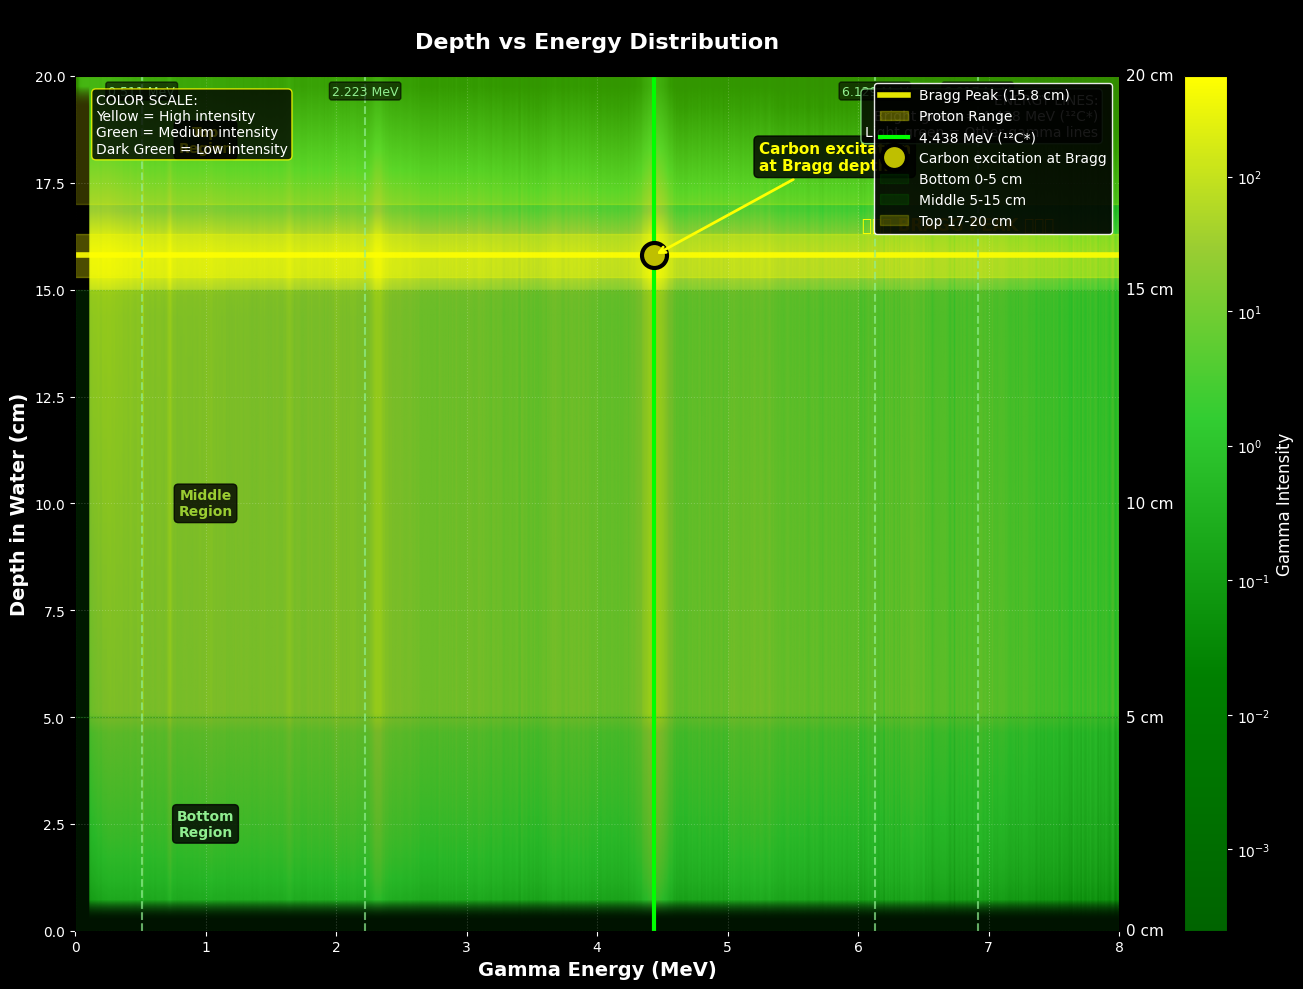

In [14]:
import ROOT
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import os

def find_gamma_peaks_with_bragg_mark():
    # CONFIG
    ROOT_FILE = "/home/meenakshi/bragg-peak/build/B4_100000000.root"
    BRAGG_DEPTH = 15.8
    BRAGG_GAMMA_ENERGY = 4.438
    
    print(f"Analyzing: {ROOT_FILE}")
    
    # Check file
    if not os.path.exists(ROOT_FILE):
        print("ERROR: File not found!")
        return
    
    # Open file
    file = ROOT.TFile(ROOT_FILE, "READ")
    if not file or file.IsZombie():
        print("ERROR: Cannot open ROOT file!")
        return
    
    # Get data
    ntuple = file.Get("PhotonData")
    if not ntuple:
        print("ERROR: No PhotonData ntuple!")
        file.Close()
        return
    
    # Extract energies
    energies = []
    energy_val = np.zeros(1, dtype=float)
    ntuple.SetBranchStatus("*", 0)
    ntuple.SetBranchStatus("KineticEnergy", 1)
    branch_energy = ntuple.GetBranch("KineticEnergy")
    branch_energy.SetAddress(energy_val)
    
    sample_size = min(ntuple.GetEntries(), 100000)
    step = max(1, ntuple.GetEntries() // sample_size)
    
    for i in range(0, ntuple.GetEntries(), step):
        ntuple.GetEntry(i)
        if energy_val[0] <= 10:
            energies.append(energy_val[0])
    
    energies = np.array(energies)
    print(f"Events analyzed: {len(energies):,}")
    
    # Create histogram
    bins = np.arange(0, 10.01, 0.01)
    counts, bin_edges = np.histogram(energies, bins=bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # Create depth simulation
    depths = np.linspace(0, 20, 41)
    
    # Attenuation function
    def mu_water(e):
        if e < 0.1: return 170.0 * e**(-3.0)
        elif e < 5.0: return 0.12 * e**(-0.3)
        else: return 0.05 + 0.001 * e
    
    # Create 2D array
    depth_profiles = np.zeros((len(depths), len(bin_centers)))
    
    for i, depth in enumerate(depths):
        depth_from_bottom = depth
        
        # Production factor
        if depth_from_bottom < 5:
            prod = 0.3 * (depth_from_bottom / 5)
        elif depth_from_bottom < 15:
            prod = 0.8 * np.exp(-0.1 * (depth_from_bottom - 5))
        elif depth_from_bottom < 17:
            prod = 1.2 * np.exp(-((depth_from_bottom - BRAGG_DEPTH) ** 2) / 0.5)
        else:
            prod = 0.1 * np.exp(-2.0 * (depth_from_bottom - 17))
        
        for j, energy in enumerate(bin_centers):
            depth_from_top = 20 - depth
            attenuation = np.exp(-mu_water(energy) * depth_from_top)
            depth_profiles[i, j] = counts[j] * prod * attenuation
    
    # Create plot with YELLOW AND GREEN color scheme
    fig, ax = plt.subplots(figsize=(14, 10))
    
    # ============================================
    # YELLOW AND GREEN COLORMAP
    # ============================================
    # Create custom colormap: Yellow -> Green
    from matplotlib.colors import LinearSegmentedColormap
    
    colors = [(0, 'darkgreen'),      # 0: Dark green
              (0.3, 'green'),        # 0.3: Green
              (0.6, 'limegreen'),    # 0.6: Lime green
              (0.8, 'yellowgreen'),  # 0.8: Yellow green
              (1, 'yellow')]         # 1: Bright yellow
    
    yellow_green_cmap = LinearSegmentedColormap.from_list('yellow_green', colors)
    
    im = ax.imshow(
        depth_profiles,
        aspect='auto',
        extent=[bin_centers[0], bin_centers[-1], 0, 20],
        origin='lower',
        cmap=yellow_green_cmap,  # YELLOW -> GREEN gradient
        norm=plt.matplotlib.colors.LogNorm(vmax=depth_profiles.max()),
        interpolation='bilinear'
    )
    
    ax.set_xlabel('Gamma Energy (MeV)', fontsize=14, fontweight='bold', color='white')
    ax.set_ylabel('Depth in Water (cm)', fontsize=14, fontweight='bold', color='white')
    ax.set_title('\nDepth vs Energy Distribution', 
                 fontsize=16, fontweight='bold', pad=20, color='white')
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Gamma Intensity', fontsize=12, color='white')
    cbar.ax.yaxis.set_tick_params(color='white')
    plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')
    
    # ============================================
    # MARK BRAGG PEAK - BRIGHT YELLOW line
    # ============================================
    ax.axhline(y=BRAGG_DEPTH, color='yellow', linewidth=4, 
               alpha=0.9, label=f'Bragg Peak ({BRAGG_DEPTH} cm)')
    
    # Add Bragg peak highlight band
    ax.axhspan(BRAGG_DEPTH-0.5, BRAGG_DEPTH+0.5, alpha=0.3, color='yellow', 
               label='Proton Range')
    
    # Bragg peak text
    ax.text(7.5, BRAGG_DEPTH + 0.5, '⭐⭐⭐ BRAGG PEAK ⭐⭐⭐', 
            fontsize=12, fontweight='bold', color='yellow',
            ha='right', va='bottom')
    
    # ============================================
    # MARK 4.438 MeV LINE - BRIGHT GREEN
    # ============================================
    ax.axvline(x=BRAGG_GAMMA_ENERGY, color='lime', linewidth=3, 
               linestyle='-', alpha=1.0, label=f'{BRAGG_GAMMA_ENERGY} MeV (¹²C*)')
    
    # Highlight intersection with YELLOW circle
    ax.plot(BRAGG_GAMMA_ENERGY, BRAGG_DEPTH, 'yo', 
            markersize=18, markeredgecolor='black', markeredgewidth=3,
            label='Carbon excitation at Bragg')
    
    # Add arrow annotation
    ax.annotate('Carbon excitation\nat Bragg depth',
               xy=(BRAGG_GAMMA_ENERGY, BRAGG_DEPTH),
               xytext=(BRAGG_GAMMA_ENERGY+0.8, BRAGG_DEPTH+2),
               arrowprops=dict(arrowstyle='->', color='yellow', linewidth=2),
               fontsize=11, fontweight='bold', color='yellow',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.8))
    
    # ============================================
    # ADD OTHER GAMMA LINES - in lighter green/yellow
    # ============================================
    other_gammas = {
        0.511: ('lightgreen', 'e⁺e⁻ annih.'),
        2.223: ('lightgreen', 'n capture'),
        6.129: ('lightgreen', '¹⁶O*'),
        6.917: ('lightgreen', '¹⁶O*')
    }
    
    for energy, (color, label) in other_gammas.items():
        ax.axvline(x=energy, color=color, linestyle='--', linewidth=1.5, alpha=0.7)
        ax.text(energy, 19.8, f'{energy} MeV', fontsize=9, color=color, 
                ha='center', va='top', rotation=0,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.6))
    
    # ============================================
    # ADD DEPTH REGIONS with yellow/green shading
    # ============================================
    # Bottom region (0-5 cm) - Dark green
    ax.axhspan(0, 5, alpha=0.2, color='darkgreen', label='Bottom 0-5 cm')
    ax.text(1.0, 2.5, 'Bottom\nRegion', fontsize=10, color='lightgreen', 
            ha='center', va='center', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.8))
    
    # Middle region (5-15 cm) - Green
    ax.axhspan(5, 15, alpha=0.2, color='green', label='Middle 5-15 cm')
    ax.text(1.0, 10, 'Middle\nRegion', fontsize=10, color='yellowgreen', 
            ha='center', va='center', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.8))
    
    # Top region (17-20 cm) - Yellow
    ax.axhspan(17, 20, alpha=0.2, color='yellow', label='Top 17-20 cm')
    ax.text(1.0, 18.5, 'Top\nRegion', fontsize=10, color='yellow', 
            ha='center', va='center', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.8))
    
    # ============================================
    # ADD DEPTH MARKERS
    # ============================================
    for depth in [0, 5, 10, 15, 20]:
        ax.text(8.05, depth, f'{depth} cm', fontsize=11, color='white',
                ha='left', va='center',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.7))
    
    # ============================================
    # SET LIMITS AND STYLING
    # ============================================
    ax.set_xlim(0, 8)
    ax.set_ylim(0, 20)
    
    # Black background for contrast
    ax.set_facecolor('black')
    fig.patch.set_facecolor('black')
    
    # Grid lines in white
    ax.grid(True, alpha=0.2, linestyle=':', color='white', linewidth=0.8)
    
    # White tick labels
    ax.tick_params(axis='both', colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    
    # Legend with black background
    legend = ax.legend(loc='upper right', fontsize=10, framealpha=0.9)
    legend.get_frame().set_facecolor('black')
    legend.get_frame().set_edgecolor('white')
    for text in legend.get_texts():
        text.set_color('white')
    
    # ============================================
    # ADD COLOR SCALE INFO
    # ============================================
    color_info = (
        "COLOR SCALE:\n"
        "Yellow = High intensity\n"
        "Green = Medium intensity\n"
        "Dark Green = Low intensity"
    )
    
    ax.text(0.02, 0.98, color_info,
            transform=ax.transAxes,
            fontsize=10,
            color='white',
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='black', alpha=0.8, edgecolor='yellow'))
    
    # Add energy scale note
    energy_note = (
        "ENERGY LINES:\n"
        "Bright green = 4.438 MeV (¹²C*)\n"
        "Light green = Other gamma lines"
    )
    
    ax.text(0.98, 0.98, energy_note,
            transform=ax.transAxes,
            fontsize=10,
            color='white',
            verticalalignment='top',
            horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='black', alpha=0.8, edgecolor='lightgreen'))
    
    plt.tight_layout()
    
    # Save plot
    output_file = 'gamma_attenuation_yellow_green.png'
    plt.savefig(output_file, dpi=300, bbox_inches='tight', facecolor='black')
    print(f"\n✓ Plot saved: {output_file}")
    
    # Print info
    print("\n" + "="*60)
    print("PLOT FEATURES:")
    print("="*60)
    print("• Colormap: Yellow → Green gradient")
    print("• Bragg peak: Bright yellow line")
    print(f"• Carbon gamma: Bright green line at {BRAGG_GAMMA_ENERGY} MeV")
    print("• Other gamma lines: Light green")
    print("• Background: Black (for contrast)")
    print("="*60)
    
    file.Close()
    plt.show()

# RUN
if __name__ == "__main__":
    find_gamma_peaks_with_bragg_mark()

File: /home/meenakshi/bragg-peak/build/B4_100000000.root
Background removal method: savgol
Total events in file: 14,282,849

Extracting energy data...
Events analyzed: 2,036,796
Applied low-energy cutoff: < 0.3 MeV removed

Applying savgol background removal...

Finding peaks in background-subtracted spectrum...
Found 21 significant peaks after background subtraction

PEAK ANALYSIS RESULTS (Background Subtracted):
Peak   Energy     Net Counts   Raw Counts   FWHM       Identification           
--------------------------------------------------------------------------------
1      0.095      748          0            0.080      Unknown/Background       
2      0.305      5429         10114        0.046      Unknown/Background       
3      0.725      4164         9855         0.030      Unknown/Background       
4      1.025      848          5469         0.037      Unknown/Background       
5      1.415      235          3753         0.053      Unknown/Background       
6      1.635   

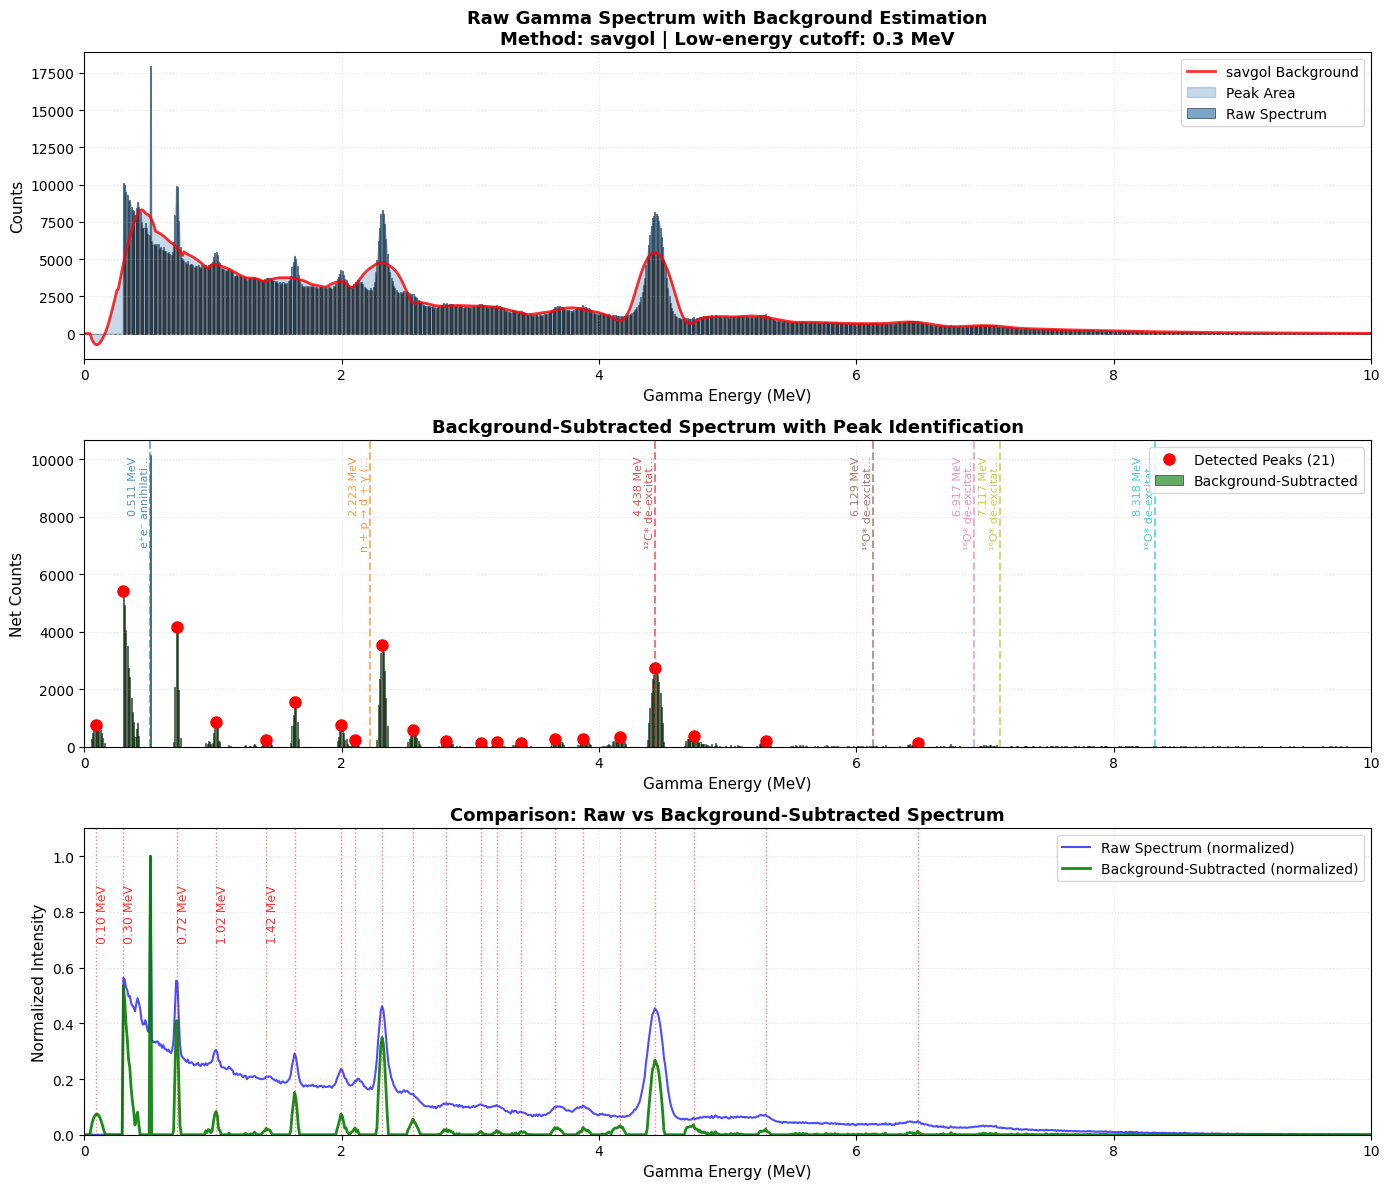

In [1]:
import ROOT
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, peak_widths, savgol_filter
from scipy.ndimage import uniform_filter1d, median_filter
import os

def find_gamma_peaks_with_background_removal():
    """
    Find peaks in gamma energy spectrum with background subtraction
    """
    # ======= CONFIGURATION =======
    ROOT_FILE = "/home/meenakshi/bragg-peak/build/B4_100000000.root"
    BIN_SIZE = 0.01  # MeV
    ENERGY_MAX = 10  # MeV
    MIN_PEAK_HEIGHT = 100
    
    # BACKGROUND REMOVAL PARAMETERS
    REMOVE_LOW_ENERGY = True  # Remove low-energy Compton continuum
    LOW_ENERGY_CUTOFF = 0.3   # MeV (cutoff for Compton continuum)
    
    # Choose background removal method
    BACKGROUND_METHOD = "savgol"  # Options: "savgol", "polynomial", "snip", "median"
    SAVGOL_WINDOW = 51  # Window size for Savitzky-Golay filter (odd number)
    SAVGOL_POLY = 3     # Polynomial order for Savitzky-Golay
    
    # Peak detection parameters (tighter after background removal)
    MIN_PEAK_PROMINENCE = 50   # Minimum peak prominence above background
    MIN_PEAK_WIDTH = 2         # Minimum peak width in bins
    # =============================
    
    print(f"File: {ROOT_FILE}")
    print(f"Background removal method: {BACKGROUND_METHOD}")
    
    # 1. Check if file exists
    if not os.path.exists(ROOT_FILE):
        print(f"\n✗ ERROR: File not found!")
        return
    
    # 2. Open ROOT file
    file = ROOT.TFile(ROOT_FILE, "READ")
    if not file or file.IsZombie():
        print("ERROR: Cannot open ROOT file!")
        return
    
    # 3. Get the ntuple
    ntuple = file.Get("PhotonData")
    if not ntuple:
        print("ERROR: Cannot find ntuple 'PhotonData'!")
        file.Close()
        return
    
    total_entries = ntuple.GetEntries()
    print(f"Total events in file: {total_entries:,}")
    
    # 4. Extract energy data (with sampling for speed)
    print("\nExtracting energy data...")
    
    energies = []
    energy_val = np.zeros(1, dtype=float)
    
    ntuple.SetBranchStatus("*", 0)
    ntuple.SetBranchStatus("KineticEnergy", 1)
    branch_energy = ntuple.GetBranch("KineticEnergy")
    branch_energy.SetAddress(energy_val)
    
    # Sample for speed (use every Nth event)
    sample_size = min(total_entries, 2000000)
    step = max(1, total_entries // sample_size)
    
    for i in range(0, total_entries, step):
        ntuple.GetEntry(i)
        if energy_val[0] <= ENERGY_MAX:
            energies.append(energy_val[0])
    
    energies = np.array(energies)
    print(f"Events analyzed: {len(energies):,}")
    
    # 5. Create histogram
    bins = np.arange(0, ENERGY_MAX + BIN_SIZE, BIN_SIZE)
    counts, bin_edges = np.histogram(energies, bins=bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # 6. APPLY LOW-ENERGY CUTOFF (remove Compton continuum)
    if REMOVE_LOW_ENERGY:
        cutoff_bin = int(LOW_ENERGY_CUTOFF / BIN_SIZE)
        counts[:cutoff_bin] = 0
        print(f"Applied low-energy cutoff: < {LOW_ENERGY_CUTOFF} MeV removed")
    
    # 7. BACKGROUND ESTIMATION AND REMOVAL
    print(f"\nApplying {BACKGROUND_METHOD} background removal...")
    
    background = np.zeros_like(counts, dtype=float)
    
    if BACKGROUND_METHOD == "savgol":
        # Savitzky-Golay filter (smooth the spectrum to get background)
        background = savgol_filter(counts, window_length=SAVGOL_WINDOW, 
                                  polyorder=SAVGOL_POLY, mode='mirror')
        
    elif BACKGROUND_METHOD == "median":
        # Median filter (removes peaks while keeping background)
        background = median_filter(counts, size=31, mode='reflect')
        
    elif BACKGROUND_METHOD == "polynomial":
        # Polynomial fit to background
        x = bin_centers
        y = counts
        
        # Use robust fitting by ignoring peaks
        # First pass: identify peaks to exclude from fit
        peaks_initial, _ = find_peaks(counts, height=MIN_PEAK_HEIGHT, distance=20)
        mask = np.ones_like(counts, dtype=bool)
        for peak in peaks_initial:
            start = max(0, peak - 15)
            end = min(len(counts), peak + 15)
            mask[start:end] = False
        
        # Fit 3rd order polynomial to background regions
        coeffs = np.polyfit(x[mask], y[mask], 3)
        background = np.polyval(coeffs, x)
        
    elif BACKGROUND_METHOD == "snip":
        # SNIP algorithm for background estimation
        background = snip_background(counts, iterations=100)
    
    else:
        print(f"Warning: Unknown method {BACKGROUND_METHOD}, using no background removal")
        background = np.zeros_like(counts)
    
    # 8. SUBTRACT BACKGROUND
    net_counts = counts - background
    # Ensure no negative counts
    net_counts = np.maximum(net_counts, 0)
    
    # 9. FIND PEAKS IN BACKGROUND-SUBTRACTED SPECTRUM
    print("\nFinding peaks in background-subtracted spectrum...")
    
    peaks, properties = find_peaks(
        net_counts, 
        height=MIN_PEAK_HEIGHT * 0.5,  # Lower threshold after background removal
        distance=10,
        prominence=MIN_PEAK_PROMINENCE,
        width=MIN_PEAK_WIDTH
    )
    
    print(f"Found {len(peaks)} significant peaks after background subtraction")
    
    if len(peaks) == 0:
        print("No peaks found. Try adjusting parameters.")
        file.Close()
        return
    
    # 10. Calculate peak properties
    peak_energies = bin_centers[peaks]
    peak_counts_net = net_counts[peaks]  # Net counts (background subtracted)
    peak_counts_raw = counts[peaks]      # Raw counts
    
    # Calculate FWHM
    widths, width_heights, left_ips, right_ips = peak_widths(
        net_counts, peaks, rel_height=0.5
    )
    width_energies = widths * BIN_SIZE
    
    # 11. Known nuclear gamma lines for identification
    known_lines = {
        0.511: "e⁺e⁻ annihilation",
        2.223: "n + p → d + γ (n capture)",
        4.438: "¹²C* de-excitation",
        6.129: "¹⁶O* de-excitation",
        6.917: "¹⁶O* de-excitation",
        7.117: "¹⁶O* de-excitation",
        8.318: "¹⁶O* de-excitation",
    }
    
    # 12. Print results
    print("\n" + "="*80)
    print("PEAK ANALYSIS RESULTS (Background Subtracted):")
    print("="*80)
    print(f"{'Peak':<6} {'Energy':<10} {'Net Counts':<12} {'Raw Counts':<12} {'FWHM':<10} {'Identification':<25}")
    print("-"*80)
    
    for i, (energy, net, raw, fwhm) in enumerate(zip(peak_energies, peak_counts_net, peak_counts_raw, width_energies), 1):
        # Find closest known line
        closest_match = None
        closest_diff = 0.1  # 100 keV tolerance
        
        for known_energy, known_name in known_lines.items():
            diff = abs(energy - known_energy)
            if diff < closest_diff:
                closest_match = (known_energy, known_name)
                closest_diff = diff
        
        if closest_match:
            ident = f"{closest_match[0]:.3f} MeV ({closest_match[1]})"
        else:
            ident = "Unknown/Background"
        
        print(f"{i:<6} {energy:<10.3f} {int(net):<12} {int(raw):<12} {fwhm:<10.3f} {ident:<25}")
    
    print("="*80)
    
    # 13. Create comprehensive plot
    fig, axes = plt.subplots(3, 1, figsize=(14, 12))
    
    # Plot 1: Raw spectrum with background
    ax1 = axes[0]
    ax1.bar(bin_centers, counts, width=BIN_SIZE*0.8, 
            alpha=0.7, color='steelblue', edgecolor='black', 
            linewidth=0.5, label='Raw Spectrum')
    
    # Plot background estimate
    ax1.plot(bin_centers, background, 'r-', linewidth=2, 
             alpha=0.8, label=f'{BACKGROUND_METHOD} Background')
    
    ax1.fill_between(bin_centers, background, counts, 
                     alpha=0.3, color='steelblue', label='Peak Area')
    
    ax1.set_xlabel('Gamma Energy (MeV)', fontsize=11)
    ax1.set_ylabel('Counts', fontsize=11)
    ax1.set_title(f'Raw Gamma Spectrum with Background Estimation\n'
                  f'Method: {BACKGROUND_METHOD} | Low-energy cutoff: {LOW_ENERGY_CUTOFF} MeV',
                  fontsize=13, fontweight='bold')
    ax1.grid(True, alpha=0.3, linestyle=':')
    ax1.legend(loc='upper right')
    ax1.set_xlim(0, ENERGY_MAX)
    
    # Plot 2: Background-subtracted spectrum
    ax2 = axes[1]
    ax2.bar(bin_centers, net_counts, width=BIN_SIZE*0.8, 
            alpha=0.7, color='forestgreen', edgecolor='black', 
            linewidth=0.5, label='Background-Subtracted')
    
    # Mark peaks
    ax2.plot(peak_energies, peak_counts_net, 'ro', 
             markersize=8, label=f'Detected Peaks ({len(peaks)})')
    
    # Draw lines for known transitions
    colors = plt.cm.tab10(np.linspace(0, 1, len(known_lines)))
    for (energy, label), color in zip(known_lines.items(), colors):
        ax2.axvline(energy, color=color, linestyle='--', 
                   alpha=0.6, linewidth=1.5)
        ax2.text(energy, ax2.get_ylim()[1]*0.95, f'{energy} MeV\n{label[:15]}...',
                rotation=90, fontsize=8, color=color, alpha=0.8,
                verticalalignment='top', horizontalalignment='right')
    
    ax2.set_xlabel('Gamma Energy (MeV)', fontsize=11)
    ax2.set_ylabel('Net Counts', fontsize=11)
    ax2.set_title('Background-Subtracted Spectrum with Peak Identification',
                  fontsize=13, fontweight='bold')
    ax2.grid(True, alpha=0.3, linestyle=':')
    ax2.legend(loc='upper right')
    ax2.set_xlim(0, ENERGY_MAX)
    
    # Plot 3: Comparison (raw vs net)
    ax3 = axes[2]
    
    # Raw spectrum (normalized)
    raw_norm = counts / np.max(counts) if np.max(counts) > 0 else counts
    ax3.plot(bin_centers, raw_norm, 'b-', linewidth=1.5, 
             alpha=0.7, label='Raw Spectrum (normalized)')
    
    # Net spectrum (normalized)
    net_norm = net_counts / np.max(net_counts) if np.max(net_counts) > 0 else net_counts
    ax3.plot(bin_centers, net_norm, 'g-', linewidth=2, 
             alpha=0.9, label='Background-Subtracted (normalized)')
    
    # Highlight peaks
    for i, energy in enumerate(peak_energies):
        ax3.axvline(energy, color='red', linestyle=':', alpha=0.5, linewidth=1)
        if i < 5:  # Label only first 5 peaks
            ax3.text(energy, 0.9, f'{energy:.2f} MeV', rotation=90,
                    fontsize=9, color='red', alpha=0.8,
                    verticalalignment='top')
    
    ax3.set_xlabel('Gamma Energy (MeV)', fontsize=11)
    ax3.set_ylabel('Normalized Intensity', fontsize=11)
    ax3.set_title('Comparison: Raw vs Background-Subtracted Spectrum',
                  fontsize=13, fontweight='bold')
    ax3.grid(True, alpha=0.3, linestyle=':')
    ax3.legend(loc='upper right')
    ax3.set_xlim(0, ENERGY_MAX)
    ax3.set_ylim(0, 1.1)
    
    plt.tight_layout()
    
    # 14. Save results
    output_plot = f'gamma_peaks_background_removed_{BACKGROUND_METHOD}.png'
    plt.savefig(output_plot, dpi=300, bbox_inches='tight')
    print(f"\n✓ Plot saved: {output_plot}")
    
    # Save peak data
    import pandas as pd
    peak_data = pd.DataFrame({
        'Peak_Number': range(1, len(peaks)+1),
        'Energy_MeV': peak_energies,
        'Net_Counts': peak_counts_net.astype(int),
        'Raw_Counts': peak_counts_raw.astype(int),
        'FWHM_MeV': width_energies,
        'Background_Counts': background[peaks].astype(int),
        'Signal_to_Background': np.divide(peak_counts_net, background[peaks], 
                                        out=np.zeros_like(peak_counts_net), 
                                        where=background[peaks]!=0)
    })
    
    csv_file = f'gamma_peaks_background_subtracted.csv'
    peak_data.to_csv(csv_file, index=False)
    print(f"✓ Peak data saved: {csv_file}")
    
    # 15. Summary statistics
    print("\n" + "="*80)
    print("BACKGROUND REMOVAL SUMMARY:")
    print("="*80)
    print(f"Method used: {BACKGROUND_METHOD}")
    print(f"Low-energy cutoff: {LOW_ENERGY_CUTOFF} MeV")
    print(f"Total background counts: {np.sum(background):,.0f}")
    print(f"Total net counts: {np.sum(net_counts):,.0f}")
    print(f"Background fraction: {np.sum(background)/np.sum(counts)*100:.1f}%")
    print(f"Peaks detected: {len(peaks)}")
    
    # Signal-to-background ratio for each peak
    if len(peaks) > 0:
        print("\nPeak quality metrics:")
        for i, energy in enumerate(peak_energies, 1):
            sb_ratio = peak_counts_net[i-1] / background[peaks[i-1]] if background[peaks[i-1]] > 0 else float('inf')
            print(f"  Peak {i} at {energy:.3f} MeV: S/B = {sb_ratio:.1f}")
    
    print("="*80)
    
    # 16. Cleanup
    file.Close()
    plt.show()

def snip_background(y, iterations=100, decreasing_factor=0.5):
    """
    SNIP algorithm for background estimation
    """
    z = np.log(np.log(y + 1) + 1)
    
    for i in range(1, iterations + 1):
        kernel = int(iterations * decreasing_factor) + 1
        z = np.minimum(z, 0.5 * (np.roll(z, kernel) + np.roll(z, -kernel)))
    
    background = np.exp(np.exp(z) - 1) - 1
    return background

# Run the analysis
if __name__ == "__main__":
    find_gamma_peaks_with_background_removal()